# EnergiAI - LUMEN

Este notebook cobre os cartões do Trello:
1. Realizar limpeza e tratamento dos dados
2. Criar base de dados energética
3. Executar análise exploratória (EDA) / Identificar padrões de consumo energético
4. Definir critérios de classificação energética
5. Treinar modelo de classificação (comparando 3 algoritmos)
6. Avaliar desempenho do modelo

## 1. Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import joblib

plt.rcParams['figure.figsize'] = (8, 5)
sns.set_style('whitegrid')

## 2. Carregando os dados

Três tabelas vindas do backend:
- `tabela_cliente.csv` -> id, tipo_pessoa (PF/PJ), tipo_imovel
- `tabela_cliente_equipamento.csv` -> quais equipamentos cada cliente tem, quantidade e uso
- `tabela_equipamento_catalogo.csv` -> potência de cada tipo de equipamento

In [2]:
df_cliente = pd.read_csv('tabela_cliente.csv')
df_equip = pd.read_csv('tabela_cliente_equipamento.csv')
df_catalogo = pd.read_csv('tabela_equipamento_catalogo.csv')

print('df_cliente:', df_cliente.shape)
print('df_equip:', df_equip.shape)
print('df_catalogo:', df_catalogo.shape)
df_cliente.head()

df_cliente: (1000, 3)
df_equip: (5571, 6)
df_catalogo: (18, 3)


,id,tipo_pessoa,tipo_imovel
0,1,PF,Residencial
1,2,PJ,Residencial
2,3,PJ,Comercial
3,4,PF,Comercial
4,5,PF,Comercial


In [3]:
df_equip.head()

,id,id_cliente,id_equipamento,quantidade,horas_uso_diario,dias_uso_mes
0,1,1,6,1,8.9,22
1,2,1,2,1,6.2,18
2,3,1,8,3,10.2,27
3,4,1,1,2,8.8,27
4,5,2,1,2,5.8,25


## 3. Limpeza e tratamento dos dados

Checando nulos, duplicidade e valores impossíveis (ex: quantidade de equipamento negativa).

In [4]:
print('Nulos em df_cliente:')
print(df_cliente.isnull().sum())
print()
print('Nulos em df_equip:')
print(df_equip.isnull().sum())
print()
print('id_cliente duplicado em df_cliente?', df_cliente['id'].duplicated().sum())

Nulos em df_cliente:
id              0
tipo_pessoa    50
tipo_imovel     0
dtype: int64

Nulos em df_equip:
id                  0
id_cliente          0
id_equipamento      0
quantidade          0
horas_uso_diario    0
dias_uso_mes        0
dtype: int64

id_cliente duplicado em df_cliente? 0


In [5]:
# checando valores impossíveis
print('quantidade mínima:', df_equip['quantidade'].min())
print('linhas com quantidade negativa:', (df_equip['quantidade'] < 0).sum())

# tratamento: remove linhas com quantidade negativa
df_equip = df_equip[df_equip['quantidade'] > 0].copy()
print('linhas após limpeza:', len(df_equip))

quantidade mínima: -2
linhas com quantidade negativa: 15
linhas após limpeza: 5556


In [6]:
mapa_categoria = {
    'Geladeira Frost Free': 'Cozinha', 'Micro-ondas': 'Cozinha', 'Airfryer': 'Cozinha',
    'Forno Elétrico': 'Cozinha', 'Liquidificador': 'Cozinha', 'Coifa / Depurador': 'Cozinha',
    'Freezer Horizontal': 'Cozinha',
    'Ar Condicionado Split': 'Climatizacao', 'Ventilador de Coluna': 'Climatizacao',
    'Chuveiro Elétrico': 'Banheiro', 'Torneira Elétrica': 'Banheiro',
    'Televisão Smart': 'Entretenimento', 'Videogame Console': 'Entretenimento',
    'Computador Desktop': 'TI', 'Servidores / TI': 'TI',
    'Robô Aspirador': 'Limpeza',
    'Maquinário Industrial': 'Industrial',
    'Iluminação Comercial (LEDs)': 'Iluminacao',
}
df_catalogo['categoria'] = df_catalogo['tipo'].map(mapa_categoria)
df_catalogo[['tipo', 'categoria']]

,tipo,categoria
0,Geladeira Frost Free,Cozinha
1,Micro-ondas,Cozinha
2,Airfryer,Cozinha
3,Forno Elétrico,Cozinha
4,Liquidificador,Cozinha
5,Coifa / Depurador,Cozinha
6,Freezer Horizontal,Cozinha
7,Ar Condicionado Split,Climatizacao
8,Ventilador de Coluna,Climatizacao
9,Chuveiro Elétrico,Banheiro


## 4. Criando a base de dados energética

Juntei as 3 tabelas em uma linha por cliente, calculei o consumo estimado (usado só pra criar o rótulo) e montei as features agregadas que o modelo vai usar de verdade.

In [7]:
df = df_equip.merge(df_catalogo, left_on='id_equipamento', right_on='id', how='left', suffixes=('', '_equip'))

# consumo estimado por linha, em kWh/mês (usado só pra construir o rótulo)
df['consumo_linha_kwh'] = (df['quantidade'] * df['horas_uso_diario'] * df['dias_uso_mes'] * df['potencia_watts']) / 1000

consumo_cliente = (
    df.groupby('id_cliente')['consumo_linha_kwh'].sum()
    .reset_index().rename(columns={'consumo_linha_kwh': 'consumo_total_kwh'})
)
consumo_cliente.head()

,id_cliente,consumo_total_kwh
0,1,1220.136
1,2,2120.433
2,3,4485.248
3,4,15215.760
4,5,3067.450


In [8]:
# features agregadas (contagens e médias, não os números exatos da fórmula)
agregado = df.groupby('id_cliente').agg(
    quantidade_equipamentos=('quantidade', 'sum'),
    diversidade_equipamentos=('id_equipamento', 'nunique'),
    horas_uso_diario_media=('horas_uso_diario', 'mean'),
    dias_uso_mes_media=('dias_uso_mes', 'mean'),
).reset_index()

def faixa_horas(h):
    if h < 4: return 'Baixo'
    elif h <= 8: return 'Medio'
    return 'Alto'

def faixa_dias(d):
    if d < 15: return 'Ocasional'
    elif d <= 25: return 'Frequente'
    return 'Constante'

agregado['faixa_uso_diario'] = agregado['horas_uso_diario_media'].apply(faixa_horas)
agregado['faixa_dias_uso'] = agregado['dias_uso_mes_media'].apply(faixa_dias)
agregado.head()

,id_cliente,quantidade_equipamentos,diversidade_equipamentos,horas_uso_diario_media,dias_uso_mes_media,faixa_uso_diario,faixa_dias_uso
0,1,7,4,8.525000,23.500000,Alto,Frequente
1,2,12,6,6.916667,24.166667,Medio,Frequente
2,3,50,6,9.616667,23.666667,Alto,Frequente
3,4,67,8,9.812500,24.375000,Alto,Frequente
4,5,26,4,6.400000,23.500000,Medio,Frequente


In [9]:
# quantidade de equipamentos por categoria (uma coluna pra cada categoria)
qtd_categoria = df.pivot_table(
    index='id_cliente', columns='categoria', values='quantidade', aggfunc='sum', fill_value=0
).reset_index()
qtd_categoria.columns = ['id_cliente'] + ['qtd_' + c.lower() for c in qtd_categoria.columns[1:]]
qtd_categoria.head()

,id_cliente,qtd_banheiro,qtd_climatizacao,qtd_cozinha,qtd_entretenimento,qtd_iluminacao,qtd_industrial,qtd_limpeza,qtd_ti
0,1,0,3,4,0,0,0,0,0
1,2,2,0,7,3,0,0,0,0
2,3,0,19,10,2,0,0,0,19
3,4,0,21,17,2,5,0,0,22
4,5,0,0,3,0,8,0,0,15


In [10]:
# montagem final: uma linha por cliente
base = df_cliente.rename(columns={'id': 'id_cliente'})
base = base.merge(agregado, on='id_cliente', how='left')
base = base.merge(qtd_categoria, on='id_cliente', how='left')
base = base.merge(consumo_cliente, on='id_cliente', how='left')

print(base.shape)

# cria a pasta se ela não existir
os.makedirs('data-science', exist_ok=True)  

print(base.shape)
base.to_csv('base_energetica.csv', index=False)
base.head()

(1000, 18)
(1000, 18)


,id_cliente,tipo_pessoa,tipo_imovel,quantidade_equipamentos,diversidade_equipamentos,horas_uso_diario_media,dias_uso_mes_media,faixa_uso_diario,faixa_dias_uso,qtd_banheiro,qtd_climatizacao,qtd_cozinha,qtd_entretenimento,qtd_iluminacao,qtd_industrial,qtd_limpeza,qtd_ti,consumo_total_kwh
0,1,PF,Residencial,7,4,8.525000,23.500000,Alto,Frequente,0,3,4,0,0,0,0,0,1220.136
1,2,PJ,Residencial,12,6,6.916667,24.166667,Medio,Frequente,2,0,7,3,0,0,0,0,2120.433
2,3,PJ,Comercial,50,6,9.616667,23.666667,Alto,Frequente,0,19,10,2,0,0,0,19,4485.248
3,4,PF,Comercial,67,8,9.812500,24.375000,Alto,Frequente,0,21,17,2,5,0,0,22,15215.760
4,5,PF,Comercial,26,4,6.400000,23.500000,Medio,Frequente,0,0,3,0,8,0,0,15,3067.450


## 5. Análise exploratória (EDA) e padrões de consumo

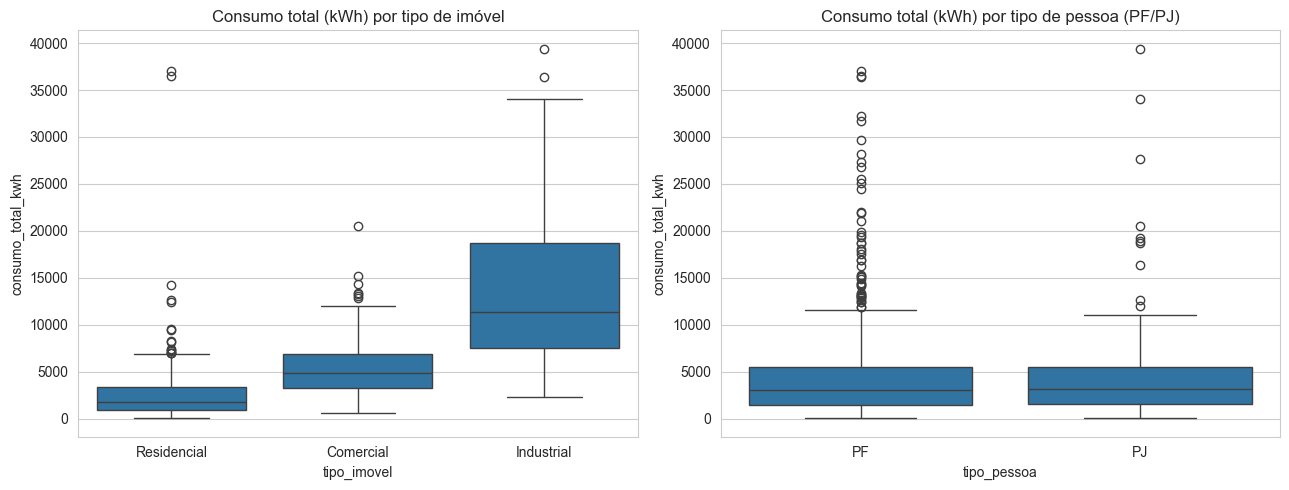

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=base, x='tipo_imovel', y='consumo_total_kwh', ax=axes[0])
axes[0].set_title('Consumo total (kWh) por tipo de imóvel')
sns.boxplot(data=base, x='tipo_pessoa', y='consumo_total_kwh', ax=axes[1])
axes[1].set_title('Consumo total (kWh) por tipo de pessoa (PF/PJ)')
plt.tight_layout()
plt.show()

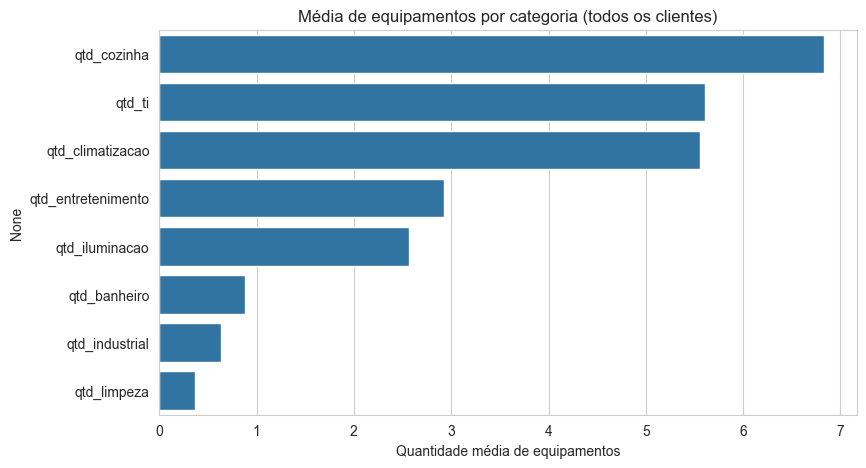

In [12]:
colunas_categoria = [c for c in base.columns if c.startswith('qtd_')]
media_categoria = base[colunas_categoria].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=media_categoria.values, y=media_categoria.index)
plt.title('Média de equipamentos por categoria (todos os clientes)')
plt.xlabel('Quantidade média de equipamentos')
plt.show()

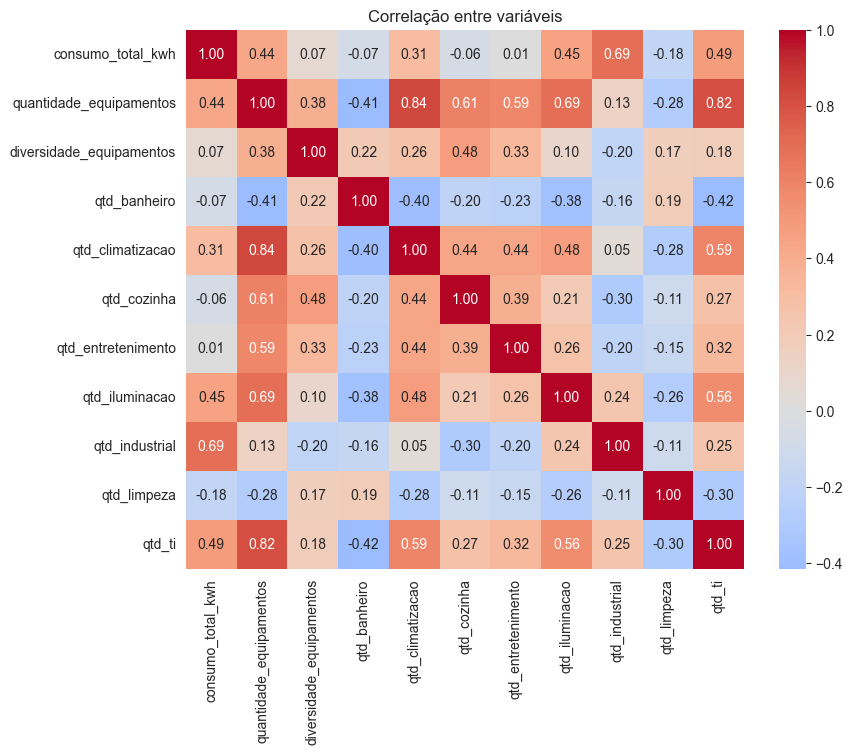

In [13]:
plt.figure(figsize=(9, 7))
colunas_corr = ['consumo_total_kwh', 'quantidade_equipamentos', 'diversidade_equipamentos'] + colunas_categoria
sns.heatmap(base[colunas_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlação entre variáveis')
plt.show()

**Leitura dos padrões:** o consumo varia bastante por tipo de imóvel (industrial > comercial > residencial, como esperado fisicamente) e a quantidade de equipamentos de climatização/industrial puxa bastante o consumo total — esses são os padrões de consumo que o cartão "Identificar padrões" pede.

## 6. Definindo os critérios de classificação energética

Duas abordagens foram testadas:

- **Quantil fixo (25%/75%):** garante uma proporção exata (25% Eficiente / 50% Moderado / 25% Ineficiente), mas é uma proporção **imposta**, não uma característica real dos dados.
- **Desvio-padrão em relação à média (adotada):** compara cada cliente com a média do seu grupo (`tipo_imovel`, já que consumo residencial/comercial/industrial têm escalas muito diferentes). Quem consome menos que **meia (0,5) desvio-padrão abaixo da média** é Eficiente; quem consome mais que **meia (0,5) desvio-padrão acima** é Ineficiente; o resto é Moderado. A proporção final sai **naturalmente desigual**, refletindo a distribuição real dos dados.

In [14]:
def classificar_perfil(grupo):
    media = grupo['consumo_total_kwh'].mean()
    desvio = grupo['consumo_total_kwh'].std()

    def rotular(valor):
        if valor <= media - 0.5 * desvio:
            return 'Eficiente'
        elif valor >= media + 0.5 * desvio:
            return 'Ineficiente'
        else:
            return 'Moderado'

    return grupo['consumo_total_kwh'].apply(rotular)

base['perfil_energetico'] = base.groupby('tipo_imovel', group_keys=False).apply(classificar_perfil)

print('Distribuição real do perfil energético:')
print(base['perfil_energetico'].value_counts())
print((base['perfil_energetico'].value_counts(normalize=True) * 100).round(1))

Distribuição real do perfil energético:
perfil_energetico
Moderado       445
Eficiente      323
Ineficiente    232
Name: count, dtype: int64
perfil_energetico
Moderado       44.5
Eficiente      32.3
Ineficiente    23.2
Name: proportion, dtype: float64


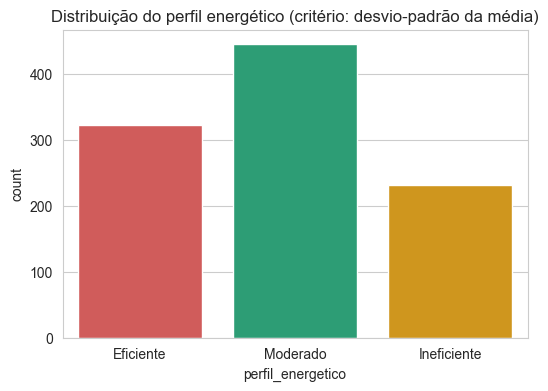

In [15]:
plt.figure(figsize=(6, 4))
ordem = ['Eficiente', 'Moderado', 'Ineficiente']
sns.countplot(data=base, x='perfil_energetico', hue='perfil_energetico', order=ordem,
              palette=['#1baf7a', '#eda100', '#e34948'], legend=False)
plt.title('Distribuição do perfil energético (critério: desvio-padrão da média)')
plt.show()

In [16]:
# consumo médio deve crescer de Eficiente -> Ineficiente
base.groupby('perfil_energetico')['consumo_total_kwh'].mean().loc[ordem].round(1)

perfil_energetico
Eficiente      1977.1
Moderado       3697.9
Ineficiente    9301.6
Name: consumo_total_kwh, dtype: float64

## 7. Treinando e comparando os 3 modelos

Random Forest, Árvore de Decisão e Regressão Logística, todos com o mesmo conjunto de features (sem os números exatos da fórmula do consumo, pra evitar que o modelo apenas "decore" o cálculo em vez de aprender um padrão real).

In [17]:
colunas_categoricas = ['tipo_pessoa', 'tipo_imovel', 'faixa_uso_diario', 'faixa_dias_uso']
colunas_numericas = [
    'quantidade_equipamentos', 'diversidade_equipamentos',
    'qtd_banheiro', 'qtd_climatizacao', 'qtd_cozinha', 'qtd_entretenimento',
    'qtd_iluminacao', 'qtd_industrial', 'qtd_limpeza', 'qtd_ti',
]

X = base[colunas_categoricas + colunas_numericas]
y = base['perfil_energetico']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

preprocessador = ColumnTransformer(
    transformers=[('categoria', OneHotEncoder(handle_unknown='ignore'), colunas_categoricas)],
    remainder='passthrough',
)

In [18]:
modelos = {
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42),
    'Árvore de Decisão': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Regressão Logística': LogisticRegression(max_iter=2000, random_state=42),
}

resultados = {}
pipelines_treinados = {}

for nome, classificador in modelos.items():
    pipe = Pipeline(steps=[('preparador', preprocessador), ('modelo', classificador)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    resultados[nome] = {
        'acuracia': accuracy_score(y_test, y_pred),
        'f1_macro': f1_score(y_test, y_pred, average='macro'),
    }
    pipelines_treinados[nome] = pipe

    print(f'--- {nome} ---')
    print(classification_report(y_test, y_pred))

--- Random Forest ---
              precision    recall  f1-score   support

   Eficiente       0.67      0.68      0.67        65
 Ineficiente       0.76      0.48      0.59        46
    Moderado       0.62      0.73      0.67        89

    accuracy                           0.66       200
   macro avg       0.68      0.63      0.64       200
weighted avg       0.67      0.66      0.65       200

--- Árvore de Decisão ---
              precision    recall  f1-score   support

   Eficiente       0.60      0.71      0.65        65
 Ineficiente       0.51      0.59      0.55        46
    Moderado       0.59      0.46      0.52        89

    accuracy                           0.57       200
   macro avg       0.56      0.59      0.57       200
weighted avg       0.57      0.57      0.57       200

--- Regressão Logística ---
              precision    recall  f1-score   support

   Eficiente       0.66      0.65      0.65        65
 Ineficiente       0.69      0.63      0.66        46

## 8. Avaliando o desempenho e escolhendo o melhor modelo

In [19]:
tabela_resultados = pd.DataFrame(resultados).T.sort_values('f1_macro', ascending=False)
tabela_resultados

,acuracia,f1_macro
Regressão Logística,0.660,0.658973
Random Forest,0.655,0.642842
Árvore de Decisão,0.570,0.569688


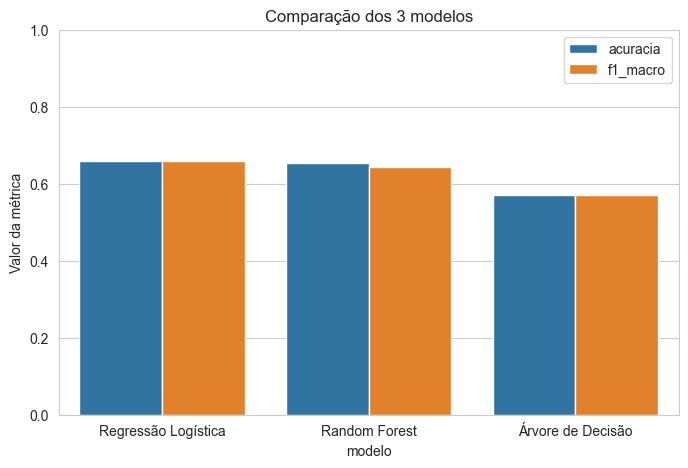

In [20]:
plt.figure(figsize=(8, 5))
tabela_plot = tabela_resultados.reset_index().rename(columns={'index': 'modelo'})
tabela_plot_melt = tabela_plot.melt(id_vars='modelo', value_vars=['acuracia', 'f1_macro'],
                                     var_name='metrica', value_name='valor')
sns.barplot(data=tabela_plot_melt, x='modelo', y='valor', hue='metrica')
plt.title('Comparação dos 3 modelos')
plt.ylim(0, 1)
plt.ylabel('Valor da métrica')
plt.legend(title='')
plt.show()

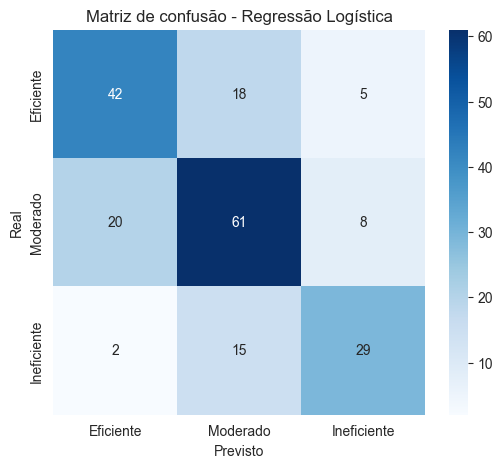

Modelo escolhido: Regressão Logística


In [21]:
# matriz de confusão do melhor modelo (maior F1 macro)
melhor_nome = tabela_resultados.index[0]
melhor_pipe = pipelines_treinados[melhor_nome]

y_pred_melhor = melhor_pipe.predict(X_test)
matriz = confusion_matrix(y_test, y_pred_melhor, labels=ordem)

plt.figure(figsize=(6, 5))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', xticklabels=ordem, yticklabels=ordem)
plt.title(f'Matriz de confusão - {melhor_nome}')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

print(f'Modelo escolhido: {melhor_nome}')

In [22]:
# salvando o modelo escolhido

os.makedirs('data-science', exist_ok=True)  # garante que a pasta existe antes de salvar

joblib.dump(melhor_pipe, 'modelo_energia.pkl')
print(f'Modelo "{melhor_nome}" salvo em modelo_energia.pkl')

Modelo "Regressão Logística" salvo em modelo_energia.pkl


## 9. Resumo

- Base de dados energética criada a partir das 3 tabelas do backend, com limpeza (removidas 15 linhas de quantidade negativa).
- Padrões identificados: consumo cresce Residencial < Comercial < Industrial; climatização e equipamentos industriais são os maiores contribuintes de consumo.
- Critério de classificação definido por desvio-padrão da média (por tipo de imóvel), gerando uma distribuição realista (não uma proporção imposta).
- Três modelos treinados e comparados (Random Forest, Árvore de Decisão, Regressão Logística); o melhor foi escolhido pela métrica F1 macro (mais justa que acurácia simples quando as classes não são perfeitamente equilibradas) e salvo em `modelo_energia.pkl`.